# Proyecto final · Dashboard EDA de producción petrolera
**GRUPO 5 · MIACD02P01**

Basado en los siete pasos de `S3_P1_Ruano.ipynb`. Archivos aportados por el usuario; no se simula producción. Ejecutar de arriba abajo con Python 3.12 y las dependencias del repositorio.

In [1]:
from pathlib import Path
import sys, json, inspect
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd()
if not (ROOT / 'src').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src import pipeline
from src.content import DICTIONARY, decisions
from src.pipeline import load_sources, clean_sources, analyze, SEED
print('Python:', sys.version.split()[0], '| Semilla:', SEED)
raw, prices_raw, catalog = load_sources(ROOT)
df, prices, audit, conflicts, duplicates, coverage, fences = clean_sources(raw, prices_raw, catalog)
summary, groups, monthly, balanced, changes, comparison = analyze(df, prices)
print('Filas originales:', len(raw), '| claves consolidadas:', len(df))

Python: 3.12.14 | Semilla: 2026


Filas originales: 802 | claves consolidadas: 789


## Paso 1 · Pregunta de análisis
¿Qué mejoras y oportunidades de mejora pueden identificarse a partir de las variaciones de producción, al comparar períodos equivalentes y considerar la cobertura y calidad de los datos?

**Usuario:** analista de planificación y supervisión de producción. **Problema:** distinguir cambios productivos de diferencias en duración de meses, cobertura de activos y errores de datos. **Unidad:** activo-mes. Las conclusiones describen el archivo, no la producción nacional ni causas operativas.

In [2]:
display(pd.DataFrame([{'pregunta': 'Evolución y concentración', 'unidad': 'activo-mes', 'salida': 'volúmenes y tasas por activo'}, {'pregunta': 'Asociación con precio', 'unidad': 'mes de una cohorte fija', 'salida': 'correlación descriptiva de cambios'}]))

,pregunta,unidad,salida
0,Evolución y concentración,activo-mes,volúmenes y tasas por activo
1,Asociación con precio,mes de una cohorte fija,correlación descriptiva de cambios


## Paso 2 · Origen y estructura
Copias inmutables de un XLSX de producción, un CSV de precios y un CSV de nomenclatura. Las unidades de volumen se interpretan según la ficha de Datos Abiertos Ecuador (BPPM/MPC); los archivos no contienen un diccionario propio. La identidad exacta con los recursos oficiales no está certificada. El CSV del precio explicita USD/barril. AB16 no tiene nomenclatura y permanece sin inventar equivalencias.

El nombre «acumulada» del XLSX agrupa una historia mensual; no se diferencia la serie como si fuera acumulado anual. Esta interpretación se apoya en la ficha mensual y en los valores que suben y bajan dentro del año.

In [3]:
print('Dimensiones de las tres fuentes:', raw.shape, prices_raw.shape, catalog.shape)
raw.info()
display(raw.describe(include='all'))
display(pd.DataFrame(DICTIONARY, columns=['tabla','campo','tipo','unidad','regla']))

Dimensiones de las tres fuentes: (802, 5) (67, 2) (15, 2)
<class 'pandas.DataFrame'>
RangeIndex: 802 entries, 0 to 801
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AÑO     802 non-null    int64  
 1   MES     802 non-null    int64  
 2   ACTIVO  802 non-null    str    
 3   CRUDO   802 non-null    float64
 4   GAS     802 non-null    float64
dtypes: float64(2), int64(2), str(1)
memory usage: 31.5 KB


,AÑO,MES,ACTIVO,CRUDO,GAS
count,802.000000,802.000000,802,8.020000e+02,802.000000
unique,NaN,NaN,16,NaN,NaN
top,NaN,NaN,AM,NaN,NaN
freq,NaN,NaN,57,NaN,NaN
mean,2023.887781,6.213217,NaN,8.026312e+05,239749.285963
std,1.364752,3.357690,NaN,7.386164e+05,217471.264774
min,2022.000000,1.000000,NaN,9.444000e+01,0.000000
25%,2023.000000,3.000000,NaN,3.000267e+05,76062.094500
50%,2024.000000,6.000000,NaN,4.745542e+05,166751.078500
75%,2025.000000,9.000000,NaN,1.376390e+06,310219.257500


,tabla,campo,tipo,unidad,regla
0,producción,AÑO / anio,int64,año calendario,2022-2026; parte de la clave
1,producción,MES / mes,int64,mes calendario,1-12; parte de la clave
2,producción,ACTIVO / activo,string,código nominal,16 códigos observados; parte de la clave
3,producción,CRUDO / crudo,float64,barriles mensuales*,Volumen observado; 1 contradicción queda NA
4,producción,GAS / gas,float64,MPC mensuales*,Miles de pies cúbicos; 2 contradicciones queda...
5,precio,Período / fecha,datetime64,primer día del mes,67 meses desde 2021-01 hasta 2026-07; clave única
6,precio,Precio... / precio_usd_barril,float64,USD por barril,"Indicador mensual agregado, no cotización por ..."
7,catálogo,Activo / nombre_activo,string,nombre nominal,15 nombres; AB16 no está en el catálogo
8,catálogo,Nomenclatura / activo,string,código nominal,Clave única usada para unión muchos-a-uno
9,derivada,fecha,datetime64,primer día del mes,Construida desde anio y mes en producción


**Resultado e interpretación:** 802 filas originales de producción, 56 meses y 16 códigos. Los 67 precios cubren enero de 2021 a julio de 2026. No todos los activos tienen igual cobertura; producción de agosto de 2026 se conserva sin precio.

## Paso 3 · Análisis univariado
Se analiza la base consolidada sin imputar ni eliminar extremos. La auditoría se desarrolla en el paso 5. Media y mediana responden a preguntas distintas; la distribución reúne activos de escalas diferentes.

,crudo,gas,crudo_diario
count,7.880000e+02,787.000000,788.000000
mean,8.012652e+05,239501.382949,26333.685624
median,4.687037e+05,166345.204000,15462.182903
std,7.380503e+05,217272.755611,24231.134481
skew,9.055347e-01,1.035647,0.899849
min,9.444000e+01,0.000000,3.148000
max,2.456959e+06,842315.040000,80458.404333


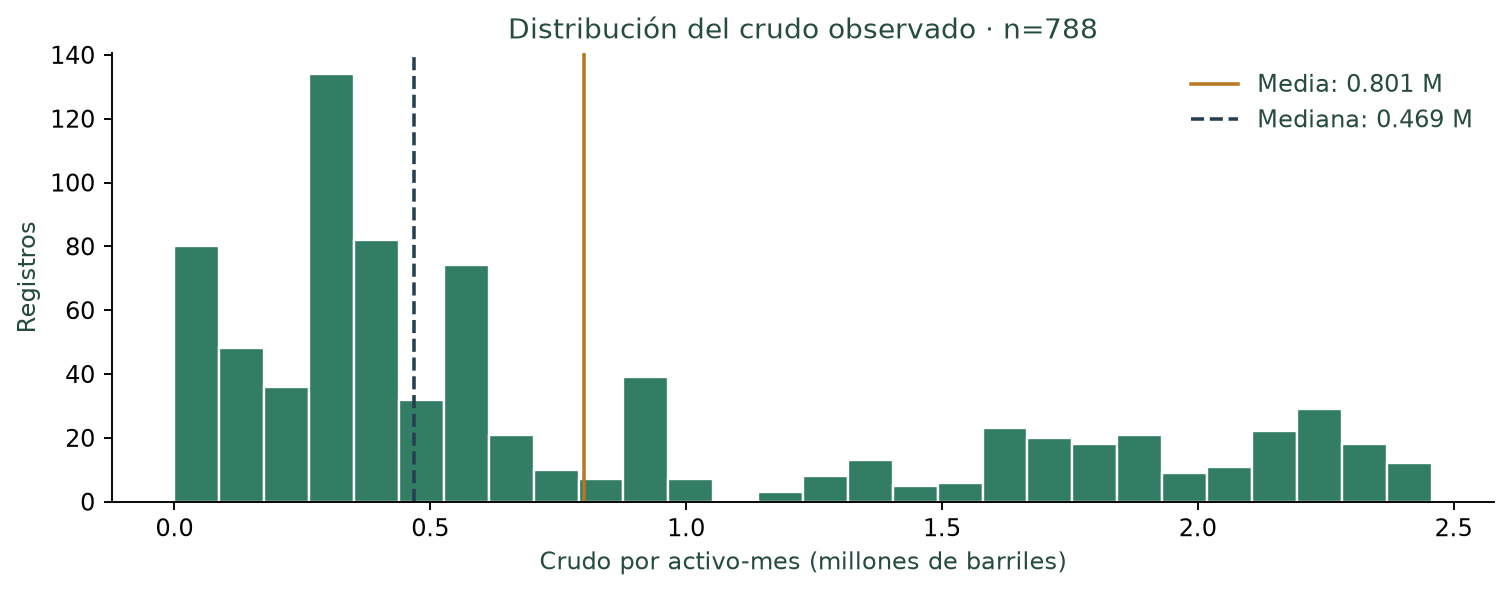

In [4]:
display(df[['crudo','gas','crudo_diario']].agg(['count','mean','median','std','skew','min','max']))
display(Image(filename=str(ROOT/'reportes/figuras/01_distribucion.png')))

**Interpretación:** crudo tiene n=788 valores válidos, media 801,265.21, mediana 468,703.71 y desviación 738,050.31 barriles por activo-mes. La asimetría 0.906 y la media mayor que la mediana muestran una cola superior. No equivalen al rendimiento de un activo típico constante ni a crecimiento temporal.

## Paso 4 · Análisis bivariado
Para precio-producción se usa una cohorte fija con crudo válido en los 56 meses. El precio se une por mes una sola vez. La tasa diaria controla la distinta duración de los meses. Se examinan niveles y cambios mensuales; no se repite el precio por activo para inflar n.

,fecha,crudo,gas,n_activos,n_crudo,n_gas,dias_mes,precio_usd_barril,crudo_diario,gas_diario
0,2022-01-01,11007063.32,3254225.028,13,13,13,31,77.62,355066.558710,104975.000903
1,2022-02-01,10423601.87,3044693.435,13,13,13,28,84.66,372271.495357,108739.051250
2,2022-03-01,12017841.90,3433927.665,13,13,13,31,100.38,387672.319355,110771.860161
3,2022-04-01,11612943.16,3341905.593,13,13,13,30,94.70,387098.105333,111396.853100
4,2022-05-01,11991401.75,3489740.614,13,13,13,31,101.31,386819.411290,112572.277871


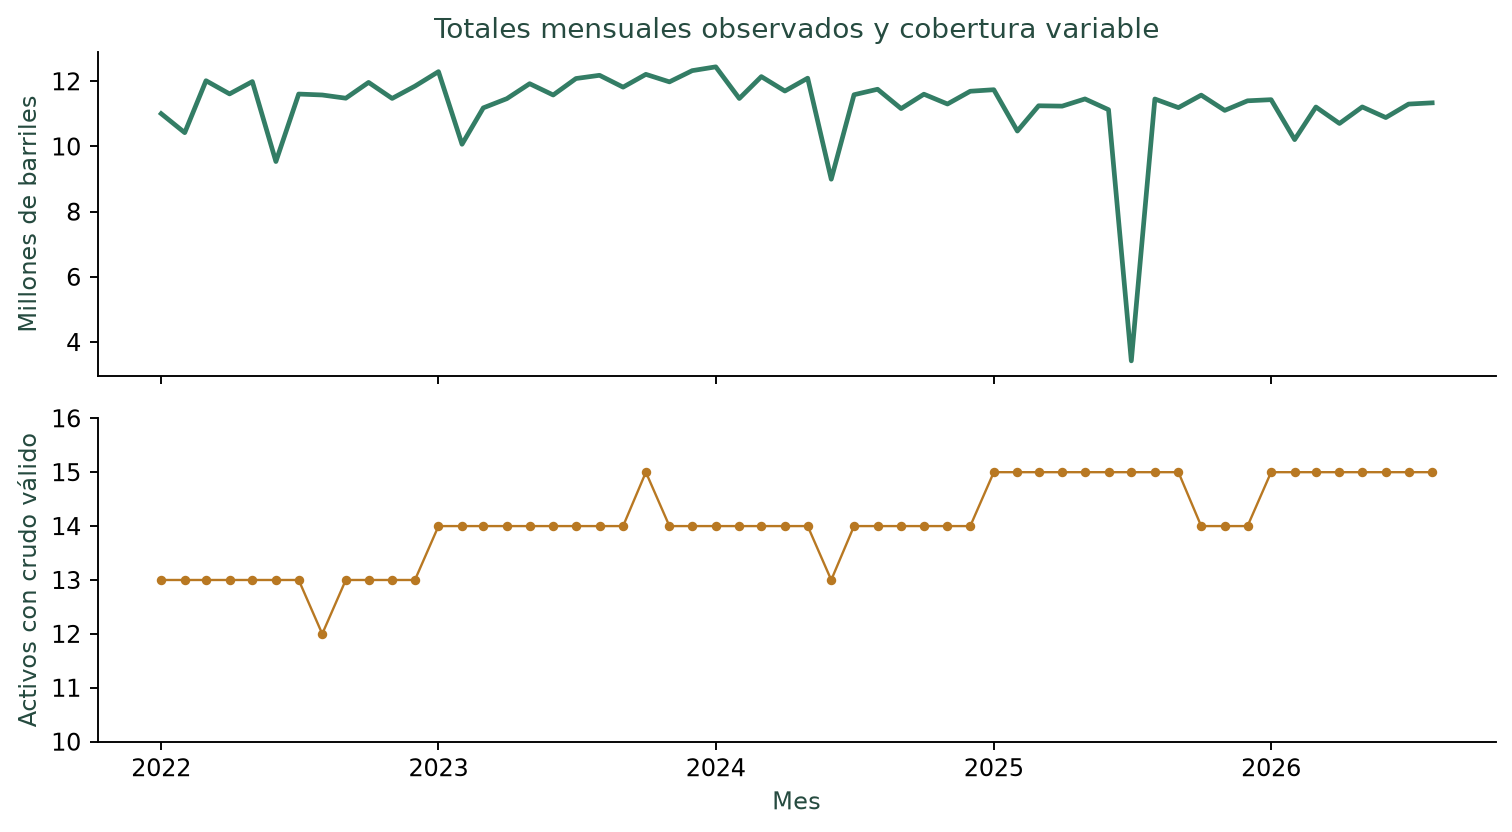

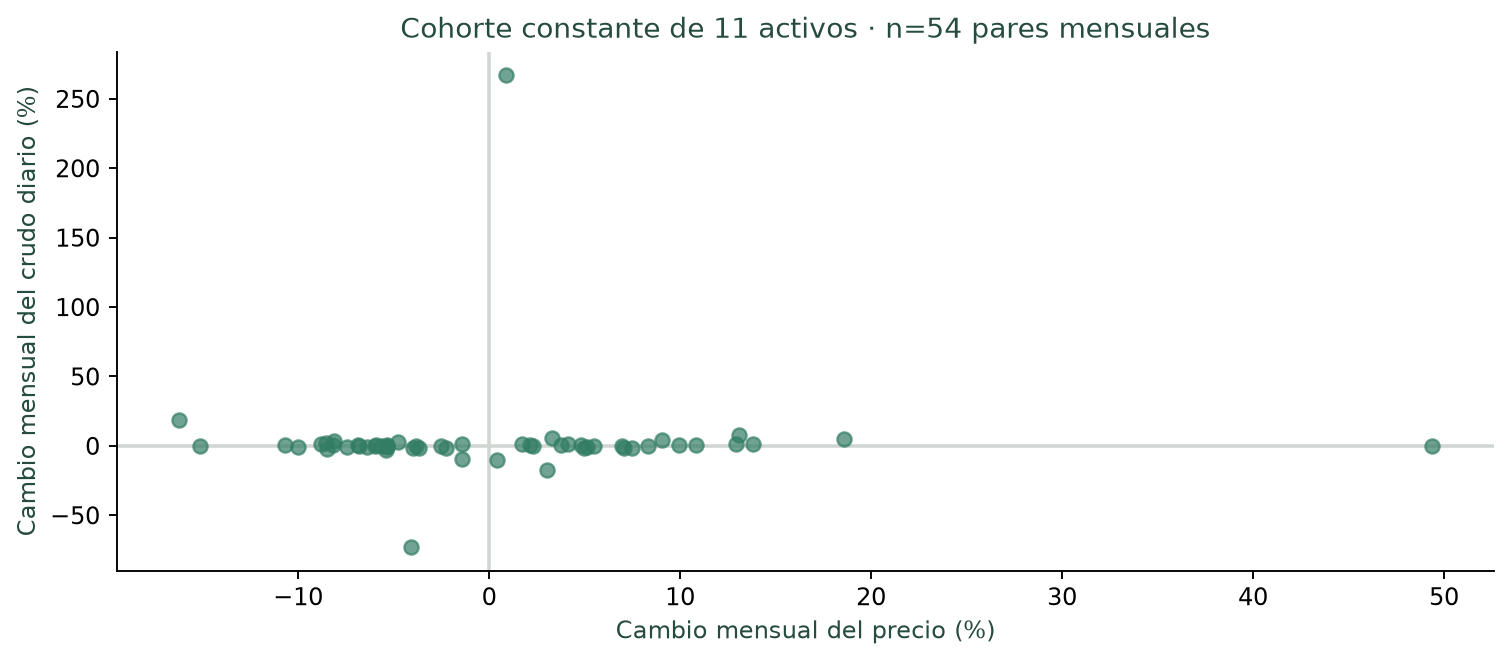

,n,r,ic95,bloque,replicas,semilla,spearman,cohorte,r_niveles
0,54,0.016568,"[-0.20176605044229481, 0.19230747830279715]",3,2000,2026,0.064227,"[AM, AP, AU, CU, EY, IN, ITT, LI, OY, PA, SA]",0.127211


In [5]:
display(monthly.head())
display(Image(filename=str(ROOT/'reportes/figuras/02_serie_cobertura.png')))
display(Image(filename=str(ROOT/'reportes/figuras/04_cambios.png')))
display(pd.DataFrame([summary['correlacion']]).drop(columns=['sensibilidad_bloque_6']))

**Interpretación:** 11 activos estables, 55 meses con precio y 54 cambios pareados. Pearson en niveles = 0.127; Pearson en cambios = 0.017; Spearman en cambios = 0.064. No aparece una asociación lineal fuerte contemporánea en esta cohorte. Esto no demuestra independencia ni descarta rezagos.

**Incertidumbre exploratoria:** remuestreo conjunto de pares en bloques circulares de 3 meses, 2.000 réplicas, semilla 2026; IC percentil [-0.202, 0.192]. Con bloques de 6 meses: [-0.202, 0.200]. Los bloques preservan dependencia local, no garantizan estacionariedad ni cobertura nominal. No se informa p-valor de independencia ficticia ni se predice producción.

## Paso 5 · Faltantes, duplicados y atípicos
Solo se consolidan observaciones de una misma clave. La tolerancia absoluta de 1e-6 absorbe diferencias de representación de Excel, sin resolver discrepancias de 0,01. Las celdas contradictorias quedan NA, conservando las demás medidas válidas de esa fila. Sin imputación. Los atípicos se marcan dentro de cada activo con 1,5 IQR de tasa diaria y se conservan.

In [6]:
display(pd.DataFrame(list(audit.items()),columns=['control','resultado']))
display(conflicts)
display(duplicates)
display(coverage[coverage.estado.eq('sin registro interior')])
display(fences)
assert not df.duplicated(['anio','mes','activo']).any()
assert len(df) == raw[['AÑO','MES','ACTIVO']].drop_duplicates().shape[0]

,control,resultado
0,filas_produccion_original,802
1,columnas_vacias_eliminadas,0
2,duplicados_exactos_extra,9
3,claves_repetidas,13
4,filas_redundantes_total,13
5,filas_limpias,789
6,celdas_conflictivas,3
7,claves_conflictivas,3
8,faltantes_crudo,1
9,faltantes_gas,2


,anio,mes,activo,variable,valores,filas_origen,tratamiento
0,2022,8,AM,gas,713407.82 | 103.69,93|110,NA; pendiente de validar con fuente
1,2022,8,AU,gas,310275.38 | 310050.89,95|115,NA; pendiente de validar con fuente
2,2022,8,LA,crudo,366668.06 | 366668.05,100|112,NA; pendiente de validar con fuente


,anio,mes,activo,crudo,gas,fila_excel
91,2022,8,AM,1253.700,713407.820,93
108,2022,8,AM,1253.700,103.690,110
92,2022,8,AP,109785.831,14019.320,94
104,2022,8,AP,109785.831,14019.320,106
93,2022,8,AU,2301395.510,310275.380,95
113,2022,8,AU,2301395.510,310050.890,115
94,2022,8,CU,769633.920,173601.770,96
109,2022,8,CU,769633.920,173601.770,111
95,2022,8,EY,952832.426,152400.210,97
105,2022,8,EY,952832.426,152400.210,107


,fecha,activo,estado,crudo_valido,gas_valido
302,2023-11-01,AV,sin registro interior,False,False
303,2023-12-01,AV,sin registro interior,False,False
304,2024-01-01,AV,sin registro interior,False,False
305,2024-02-01,AV,sin registro interior,False,False
306,2024-03-01,AV,sin registro interior,False,False
307,2024-04-01,AV,sin registro interior,False,False
308,2024-05-01,AV,sin registro interior,False,False
309,2024-06-01,AV,sin registro interior,False,False
310,2024-07-01,AV,sin registro interior,False,False
311,2024-08-01,AV,sin registro interior,False,False


,activo,variable,n,q1,q3,limite_inferior,limite_superior,n_atipicos
0,AB16,crudo_diario,36,10153.200048,11493.412500,8142.881371,13503.731177,1
1,AB16,gas_diario,36,2705.088226,3059.914934,2172.848164,3592.154996,2
2,AIT,crudo_diario,8,11038.826694,11247.671760,10725.559094,11560.939359,0
3,AIT,gas_diario,8,3240.350089,3325.007825,3113.363484,3451.994431,2
4,AM,crudo_diario,56,27.697137,34.932258,16.844456,45.784940,3
5,AM,gas_diario,55,18600.170657,21528.100086,14208.276512,25919.994231,6
6,AP,crudo_diario,56,3251.292871,3831.283782,2381.306503,4701.270150,13
7,AP,gas_diario,56,416.199900,487.173242,309.739887,593.633255,7
8,AU,crudo_diario,56,66642.811653,75618.010562,53180.013291,89080.808924,1
9,AU,gas_diario,55,8833.902857,10048.676022,7011.743110,11870.835768,1


**Resultado e interpretación:** 9 copias exactas y 13 filas redundantes en total; quedan 789 claves. LA en agosto de 2022 presenta crudo 366668,06 vs. 366668,05: falta 1 crudo. AM y AU de ese mes presentan gas contradictorio: faltan 2 gases. Hay 17 huecos interiores de AV y uno de SH; no se interpretan como producción cero. AB16 carece de nombre en 36 filas. Se conservan 18 ceros de gas, 52 marcas IQR de crudo diario y 42 de gas diario. IQR=0 de AV requiere especial cautela, no eliminación automática.

## Paso 6 · Segmentación por activo y año
Cada tabla incluye n válido, no solo total de filas. Regla descriptiva: n<12 meses implica menos de una vuelta anual; no es garantía de precisión a partir de 12. Los registros temporales pueden estar correlacionados. Para 2026/2025 se usan enero-agosto, tasas por días calendario y solo activos completos en ambos períodos.

,activo,nombre_activo,anio,n_registros,n_crudo,n_gas,n_precio,crudo_total,media_crudo_diario,mediana_crudo_diario,gas_total,grupo_pequeno
0,AB16,AB16 (sin catálogo),2023,12,12,12,12,3800026.54,10413.330339,10102.817903,1040004.840,False
1,AB16,AB16 (sin catálogo),2024,12,12,12,12,3939063.55,10762.924234,10694.943226,1032896.350,False
2,AB16,AB16 (sin catálogo),2025,12,12,12,12,4030420.11,11051.526921,11417.401683,1063770.490,False
3,AIT,Amo-Iro-Tivacuno,2026,8,8,8,7,2716245.40,11178.491388,11200.132968,800088.240,True
4,AM,Amistad,2022,12,12,11,12,15038.85,41.248130,40.343801,5107489.280,False
...,...,...,...,...,...,...,...,...,...,...,...,...
67,SH,Shushufindi,2022,12,12,12,12,22812967.69,62502.709545,64199.860444,6671401.930,False
68,SH,Shushufindi,2023,12,12,12,12,22082024.15,60473.405468,60173.421290,6323133.365,False
69,SH,Shushufindi,2024,11,11,11,11,19439705.90,57855.174629,57900.295484,5654052.239,True
70,SH,Shushufindi,2025,12,12,12,12,18878459.53,51784.056282,54574.478785,6327479.917,False


,activo,n_actual,n_anterior,diario_actual,diario_anterior,cambio_pct,cambio_diario
6,IN,8,8,12555.692140,13393.361111,-6.254360,-837.668971
3,AV,8,8,22.618889,26.417119,-14.377913,-3.798230
0,AM,8,8,27.584897,28.546144,-3.367344,-0.961247
2,AU,8,8,61618.656296,60748.374527,1.432601,870.281770
4,CU,8,8,17751.069012,16522.991728,7.432536,1228.077284
7,ITT,8,8,41540.465263,40126.357321,3.524137,1414.107942
11,PA,8,8,13002.011811,11340.791852,14.648183,1661.219959
9,LI,8,8,10411.597407,8634.504733,20.581292,1777.092675
5,EY,8,8,29269.917152,27464.491663,6.573672,1805.425490
8,LA,8,8,12178.456831,10248.306996,18.833841,1930.149835


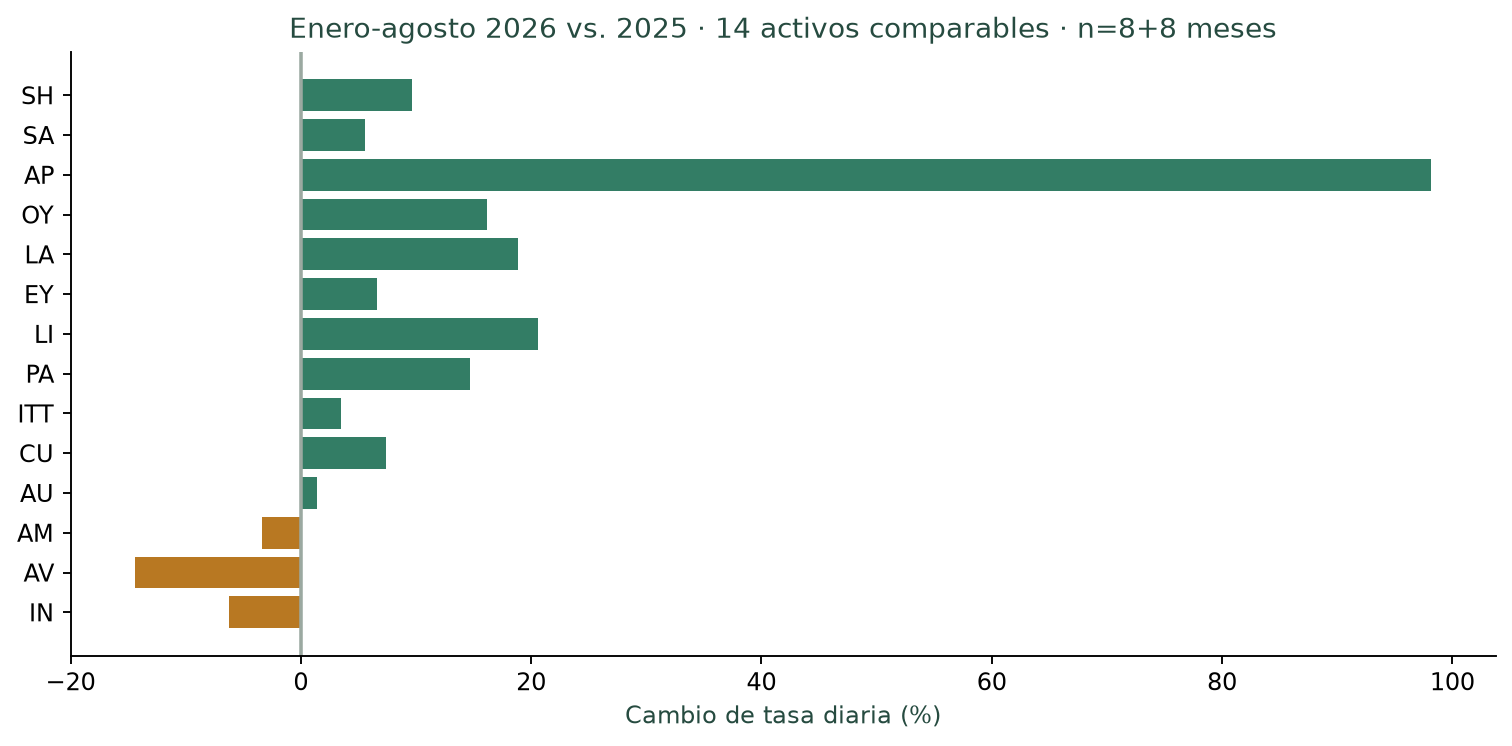

Activos comparables: ['AM', 'AP', 'AU', 'AV', 'CU', 'EY', 'IN', 'ITT', 'LA', 'LI', 'OY', 'PA', 'SA', 'SH']
Cambio de cohorte (%): 7.5347193699044634


In [7]:
display(groups)
display(comparison)
display(Image(filename=str(ROOT/'reportes/figuras/05_comparacion.png')))
print('Activos comparables:', summary['activos_comparables'])
print('Cambio de cohorte (%):', summary['cambio_comparable_pct'])

**Interpretación:** los 14 activos comparables aumentan su tasa conjunta 7.53%. IN varía -6.25% con n=8 meses en cada año. AIT y AB16 quedan fuera de esta comparación al no estar en ambos períodos completos. No se presume que un código sustituya al otro.

## Paso 7 · Hallazgos y decisiones
Los indicadores y sus límites se convierten en cuatro acciones verificables. Los umbrales de gestión son propuestas explícitas, no resultados estadísticos ni normas.

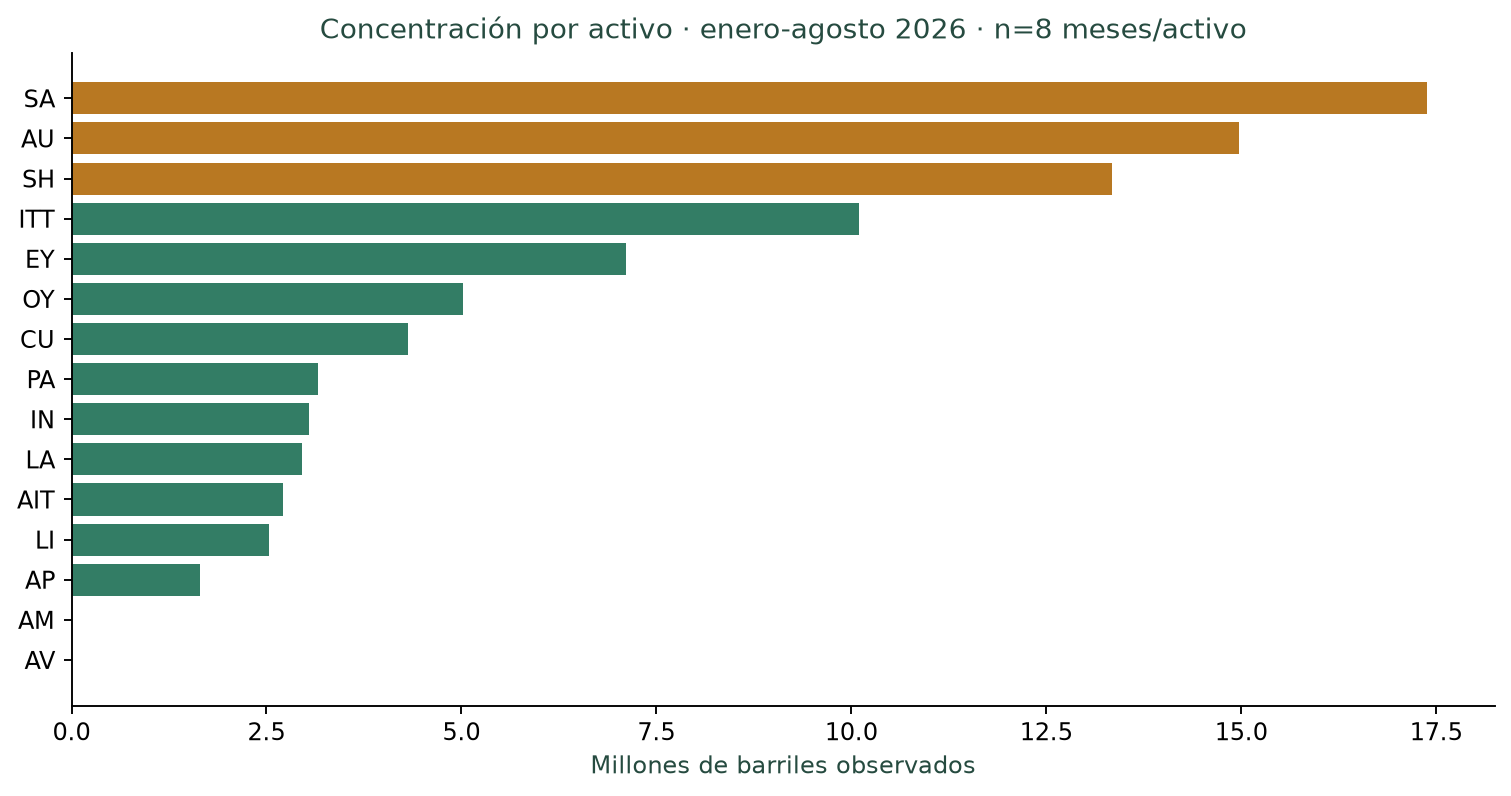

### 1. Priorizar la revisión de continuidad de SA, AU y SH

**Evidencia:** Sacha, Auca y Shushufindi concentran 51.75% del crudo de enero-agosto de 2026; 8 meses por activo. Es concentración del volumen observado.

**Accion:** Revisar semanalmente disponibilidad, paradas y mantenimiento de esos tres activos antes de reasignar recursos.

**Responsable:** Coordinación de operaciones y mantenimiento.

**Indicador:** Participación de los tres activos y tasa diaria por activo; activar revisión si cae más de 5% frente al mismo período previo.

**Limite:** El 5% es un umbral propuesto de gestión, no estimado ni normativo. No hay datos de costo, seguridad, disponibilidad ni reservas; no autoriza por sí solo inversiones.

### 2. Investigar la caída de Indillana en períodos comparables

**Evidencia:** IN registra 12,556 barriles/día en enero-agosto de 2026 y 13,393 en 2025: -6.25%, diferencia de -838 barriles/día (n=8 meses en cada año). La cohorte de 14 activos aumenta 7.53%.

**Accion:** Solicitar bitácoras de paradas y conciliación mensual de medición de IN; completar una revisión en 30 días.

**Responsable:** Ingeniería de producción del activo y responsable de datos.

**Indicador:** Variación interanual de tasa diaria y porcentaje de meses conciliados; objetivo de revisión: 100% de los 8 meses.

**Limite:** La reducción es descriptiva. No se atribuye a agotamiento o fallas sin evidencia operativa. Ocho meses no cubren una vuelta anual completa.

### 3. Corregir las brechas antes de certificar totales

**Evidencia:** Se encontraron 13 claves repetidas, 3 celdas contradictorias, 18 huecos interiores, AB16 sin catálogo y agosto de 2026 sin precio.

**Accion:** Conciliar AM, AU y LA de agosto de 2022 con la fuente, revisar las ausencias y completar la nomenclatura; mantener identificadas las sumas parciales.

**Responsable:** Administrador de datos y supervisor de medición.

**Indicador:** Claves duplicadas después de limpiar = 0; celdas conflictivas pendientes = 0 como meta; cobertura de catálogo = 100% como meta.

**Limite:** No sustituir faltantes por cero ni interpolar para cumplir la meta. Un hueco puede reflejar cobertura administrativa y requiere confirmación.

### 4. Separar la vigilancia del precio de las metas de producción

**Evidencia:** En 11 activos con cobertura constante, r entre cambios mensuales de tasa de crudo y precio es 0.017; n=54 meses pareados, IC exploratorio por bloques de 3 meses [-0.202, 0.192].

**Accion:** Mantener el precio como indicador de contexto y actualizar la comparación mensual cuando exista el nuevo dato; usar variables operativas para investigar cambios productivos.

**Responsable:** Analista de planificación y analista comercial.

**Indicador:** Número de meses pareados, cobertura de la cohorte y correlación de cambios; no emitir conclusión cuantitativa con menos de 12 pares.

**Limite:** El intervalo incluye cero y valores positivos/negativos. No prueba independencia; no es un modelo de pronóstico ni una estimación causal. Precio × producción no representa ingresos efectivos.

In [8]:
display(Image(filename=str(ROOT/'reportes/figuras/03_concentracion.png')))
for item in decisions(summary,audit):
    display(Markdown('### '+item['titulo']+'\n\n'+'\n\n'.join('**'+k.capitalize()+':** '+v for k,v in item.items() if k!='titulo')))

## Anexo técnico T1-T8
**Correspondencia propuesta:** la rúbrica nombra T1-T8 sin proporcionar sus enunciados. Los siguientes ocho apartados cubren el código, limpieza, segmentación, n y reproducibilidad; deben cotejarse con la guía oficial si se proporciona. No se presentan como transcripción de una guía inexistente.

### T1 · Carga y trazabilidad
read_excel/read_csv cargan las copias conservadas. SHA-256 impide analizar una versión distinta de la documentada. Path hace portables las rutas.

In [9]:
print(inspect.getsource(pipeline.load_sources))

def load_sources(root=ROOT):
    raw = root/'data/crudos'
    for item in json.loads((raw/'manifest.json').read_text(encoding='utf-8')):
        if hashlib.sha256((raw/item['archivo']).read_bytes()).hexdigest() != item['sha256']:
            raise ValueError('La fuente cambió: '+item['archivo'])
    production = pd.read_excel(raw/'produccion_original.xlsx', sheet_name='Hoja1')
    prices = pd.read_csv(raw/'precios_original.csv')
    catalog = pd.read_csv(raw/'activos_original.csv')
    return production, prices, catalog



### T2 · Estructura y tipos
to_numeric y to_datetime fallan ante valores inválidos; año/mes son enteros y activo es etiqueta nominal. info, shape y describe se muestran en el notebook.

In [10]:
print(inspect.getsource(pipeline.clean_sources))

def clean_sources(production, prices, catalog):
    """No modifica entradas. No resuelve contradicciones seleccionando primera/última fila."""
    empty_cols = production.columns[production.isna().all()].tolist()
    d = production.drop(columns=empty_cols).rename(columns={
        'AÑO':'anio','MES':'mes','ACTIVO':'activo','CRUDO':'crudo','GAS':'gas'}).copy()
    if set(d.columns) != set(KEY+['crudo','gas']):
        raise ValueError('Esquema de producción inesperado')
    d['fila_excel'] = np.arange(2, len(d)+2)
    for col in ['anio','mes','crudo','gas']:
        d[col] = pd.to_numeric(d[col], errors='raise')
    if d[KEY].isna().any().any() or not d.mes.between(1,12).all():
        raise ValueError('Clave o mes inválido')
    if not (d[['anio','mes']] % 1 == 0).all().all():
        raise ValueError('Año/mes no entero')
    d[['anio','mes']]=d[['anio','mes']].astype('int64')
    d['activo'] = d.activo.astype('string').str.strip().str.upper()
    if (d[['crudo','gas']] < 0).any().any(

### T3 · Duplicados y contradicciones
La clave es año-mes-activo. Se consolidan copias exactas y equivalentes con tolerancia absoluta 1e-6. Cuando un volumen discrepa se asigna NA solo a esa medida. No se escoge la primera fila.

In [11]:
print(inspect.getsource(pipeline.clean_sources))

def clean_sources(production, prices, catalog):
    """No modifica entradas. No resuelve contradicciones seleccionando primera/última fila."""
    empty_cols = production.columns[production.isna().all()].tolist()
    d = production.drop(columns=empty_cols).rename(columns={
        'AÑO':'anio','MES':'mes','ACTIVO':'activo','CRUDO':'crudo','GAS':'gas'}).copy()
    if set(d.columns) != set(KEY+['crudo','gas']):
        raise ValueError('Esquema de producción inesperado')
    d['fila_excel'] = np.arange(2, len(d)+2)
    for col in ['anio','mes','crudo','gas']:
        d[col] = pd.to_numeric(d[col], errors='raise')
    if d[KEY].isna().any().any() or not d.mes.between(1,12).all():
        raise ValueError('Clave o mes inválido')
    if not (d[['anio','mes']] % 1 == 0).all().all():
        raise ValueError('Año/mes no entero')
    d[['anio','mes']]=d[['anio','mes']].astype('int64')
    d['activo'] = d.activo.astype('string').str.strip().str.upper()
    if (d[['crudo','gas']] < 0).any().any(

### T4 · Faltantes, ceros y atípicos
No se imputa precio ni volumen. Se conservan ceros de gas e IQR fuera de cercas por activo. Un faltante no es cero y un atípico no demuestra error.

In [12]:
print(inspect.getsource(pipeline.clean_sources))

def clean_sources(production, prices, catalog):
    """No modifica entradas. No resuelve contradicciones seleccionando primera/última fila."""
    empty_cols = production.columns[production.isna().all()].tolist()
    d = production.drop(columns=empty_cols).rename(columns={
        'AÑO':'anio','MES':'mes','ACTIVO':'activo','CRUDO':'crudo','GAS':'gas'}).copy()
    if set(d.columns) != set(KEY+['crudo','gas']):
        raise ValueError('Esquema de producción inesperado')
    d['fila_excel'] = np.arange(2, len(d)+2)
    for col in ['anio','mes','crudo','gas']:
        d[col] = pd.to_numeric(d[col], errors='raise')
    if d[KEY].isna().any().any() or not d.mes.between(1,12).all():
        raise ValueError('Clave o mes inválido')
    if not (d[['anio','mes']] % 1 == 0).all().all():
        raise ValueError('Año/mes no entero')
    d[['anio','mes']]=d[['anio','mes']].astype('int64')
    d['activo'] = d.activo.astype('string').str.strip().str.upper()
    if (d[['crudo','gas']] < 0).any().any(

### T5 · Uniones y variables
merge many_to_one valida el catálogo y los precios. La unión izquierda retiene producción sin precio. Tasa diaria = volumen/días reales; log1p facilita describir asimetría.

In [13]:
print(inspect.getsource(pipeline.clean_sources))

def clean_sources(production, prices, catalog):
    """No modifica entradas. No resuelve contradicciones seleccionando primera/última fila."""
    empty_cols = production.columns[production.isna().all()].tolist()
    d = production.drop(columns=empty_cols).rename(columns={
        'AÑO':'anio','MES':'mes','ACTIVO':'activo','CRUDO':'crudo','GAS':'gas'}).copy()
    if set(d.columns) != set(KEY+['crudo','gas']):
        raise ValueError('Esquema de producción inesperado')
    d['fila_excel'] = np.arange(2, len(d)+2)
    for col in ['anio','mes','crudo','gas']:
        d[col] = pd.to_numeric(d[col], errors='raise')
    if d[KEY].isna().any().any() or not d.mes.between(1,12).all():
        raise ValueError('Clave o mes inválido')
    if not (d[['anio','mes']] % 1 == 0).all().all():
        raise ValueError('Año/mes no entero')
    d[['anio','mes']]=d[['anio','mes']].astype('int64')
    d['activo'] = d.activo.astype('string').str.strip().str.upper()
    if (d[['crudo','gas']] < 0).any().any(

### T6 · Resumen y asociación
Se distinguen suma, media y mediana. El precio se cuenta una vez por mes. Las correlaciones utilizan una cohorte constante; los cambios mensuales reducen la confusión por niveles y duración de los meses.

In [14]:
print(inspect.getsource(pipeline.analyze))

def analyze(clean,prices):
    segments=clean.groupby(['activo','nombre_activo','anio'],observed=True).agg(
        n_registros=('fecha','size'),n_crudo=('crudo','count'),n_gas=('gas','count'),
        n_precio=('precio_usd_barril','count'),crudo_total=('crudo',lambda s:s.sum(min_count=1)),
        media_crudo_diario=('crudo_diario','mean'),mediana_crudo_diario=('crudo_diario','median'),
        gas_total=('gas',lambda s:s.sum(min_count=1))).reset_index()
    segments['grupo_pequeno']=segments.n_crudo<SMALL_N
    monthly=monthly_series(clean)
    full_n=clean.fecha.nunique()
    counts=clean.groupby('activo').crudo.count()
    cohort=sorted(counts[counts==full_n].index)
    balanced=monthly_series(clean[clean.activo.isin(cohort)])
    paired=balanced.dropna(subset=['crudo_diario','precio_usd_barril']).copy()
    paired['cambio_crudo_pct']=paired.crudo_diario.pct_change(fill_method=None)*100
    paired['cambio_precio_pct']=paired.precio_usd_barril.pct_change(fill_method=None)*100
    ch

### T7 · Segmentación y n
groupby activo-año calcula n_registros y n válidos por medida. n<12 advierte cobertura inferior a una vuelta anual. La comparación 2026/2025 usa enero-agosto y 14 activos presentes en ambos períodos.

In [15]:
print(inspect.getsource(pipeline.analyze))

def analyze(clean,prices):
    segments=clean.groupby(['activo','nombre_activo','anio'],observed=True).agg(
        n_registros=('fecha','size'),n_crudo=('crudo','count'),n_gas=('gas','count'),
        n_precio=('precio_usd_barril','count'),crudo_total=('crudo',lambda s:s.sum(min_count=1)),
        media_crudo_diario=('crudo_diario','mean'),mediana_crudo_diario=('crudo_diario','median'),
        gas_total=('gas',lambda s:s.sum(min_count=1))).reset_index()
    segments['grupo_pequeno']=segments.n_crudo<SMALL_N
    monthly=monthly_series(clean)
    full_n=clean.fecha.nunique()
    counts=clean.groupby('activo').crudo.count()
    cohort=sorted(counts[counts==full_n].index)
    balanced=monthly_series(clean[clean.activo.isin(cohort)])
    paired=balanced.dropna(subset=['crudo_diario','precio_usd_barril']).copy()
    paired['cambio_crudo_pct']=paired.crudo_diario.pct_change(fill_method=None)*100
    paired['cambio_precio_pct']=paired.precio_usd_barril.pct_change(fill_method=None)*100
    ch

### T8 · Reproducibilidad y validación
Semilla 2026 y 2.000 réplicas por bloques reproducen el diagnóstico. requirements, tests, notebook ejecutado y un comando reconstruyen los resultados. No se generan observaciones petroleras ficticias.

In [ ]:
print(inspect.getsource(pipeline.block_bootstrap_correlation))

def block_bootstrap_correlation(x,y,seed=SEED,reps=2000,block=3):
    """IC percentil exploratorio por bloques móviles circulares de pares temporales."""
    x,y=np.asarray(x),np.asarray(y)
    if len(x)<12 or np.std(x)==0 or np.std(y)==0:
        return {'n':len(x),'r':None,'ic95':None,'bloque':block,'replicas':reps,'semilla':seed}
    rng=np.random.default_rng(seed); n=len(x); rs=[]
    for _ in range(reps):
        starts=rng.integers(0,n,size=int(np.ceil(n/block)))
        idx=((starts[:,None]+np.arange(block))%n).ravel()[:n]
        if np.std(x[idx])>0 and np.std(y[idx])>0: rs.append(np.corrcoef(x[idx],y[idx])[0,1])
    return {'n':n,'r':float(np.corrcoef(x,y)[0,1]),'ic95':np.quantile(rs,[.025,.975]).tolist(),
            'bloque':block,'replicas':reps,'semilla':seed}



## Alcance y fuentes
- S3_P1: método de siete pasos. S3_P2: interpretación prudente de asociación e incertidumbre. S3_P3: separación de evaluación y modelos; no se fuerza predicción sin pregunta predictiva. S3_P4: módulos, rutas, versiones y Git.
- S3_EDA_Critico_Reel_Turismo y S3_reel: sumas vs. promedios y n de grupos.
- EDA_Produccion_Petrolera_Ecuador_Ruano: antecedente del dominio; se usan exclusivamente los tres archivos nuevos.
- [Datos Abiertos Ecuador](https://www.datosabiertos.gob.ec/dataset/produccion-mensual-petroecuador).
- [BCE, definición del precio](https://contenido.bce.fin.ec/).

`python -m src.reproducir` reconstruye análisis, gráficos, dashboard, notebook ejecutado y PDF. Las fuentes se verifican con SHA-256. El ZIP no requiere descargas de datos.